# Real PD Meniscus Segmentation — Analysis

Compares three model predictions against ground truth masks on real PD scans:
- **Baseline**: pretrained 5-class model, no fine-tuning
- **v1**: fine-tuned on 55 DESS patients (run_001, ~0.49 Dice on val)
- **v2**: fine-tuned on 124 DESS patients (run_002, ~0.83 Dice on val)

Ground truth labels: `1 = meniscus` (no lateral/medial split)  
Prediction labels: `1 = lateral, 2 = medial` → merged to `1 = meniscus` for Dice

In [61]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import zoom

In [62]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE = "/Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2"

PD_DIR       = f"{BASE}/data/iu-dataset/pd-files"
GT_DIR       = f"{BASE}/data/iu-dataset/segmentation_masks"
PRED_V1_DIR  = f"{BASE}/real_pd_predictions"          # fine-tuned 55 patients
PRED_V2_DIR  = f"{BASE}/real_pd_predictions_v2"       # fine-tuned 124 patients
PRED_BL_DIR  = f"{BASE}/real_pd_predictions_baseline" # no fine-tuning

In [63]:
def extract_patient_id(path):
    return Path(path).name.split("_")[0]

def patients_in_dir(directory, pattern="*.nii*"):
    files = glob.glob(os.path.join(directory, pattern))
    return {extract_patient_id(f): f for f in files
            if ".seg.nrrd" not in f and ".labels.csv" not in f}

def load_vol(path):
    img = nib.load(path)
    return np.asarray(img.get_fdata()), img.affine

# ── Mirror process_volume() from preprocess.py exactly ──────────────────────
def preprocess_gt_mask(path):
    """
    Apply the same RAS reorientation + in-plane isotropic resample + 384x384
    resize as process_volume() in preprocess.py — but with order=0 (nearest-
    neighbour) to preserve integer mask labels, and no intensity normalisation.

    process_volume steps:
      1. sitk.DICOMOrient → "RAS"
         sitk array is (S,A,R), transpose → (R,A,S)  ← slices on axis 0
      2. Resample A,S to isotropic (finer of sp_A, sp_S)
      3. Resize (A,S) → 384x384
      4. Normalise  ← SKIPPED for masks

    We replicate steps 1-3 using nibabel (available locally).
    nib.as_closest_canonical() is the nibabel equivalent of DICOMOrient RAS.
    nibabel get_fdata() returns (x,y,z) = (R,A,S) in RAS+ space, so axis 0
    is already the through-plane R axis — same result as the sitk transpose.
    """
    img = nib.load(path)
    img = nib.as_closest_canonical(img)          # step 1: reorient to RAS+
    arr = img.get_fdata().astype(np.float32)     # (R, A, S), slices on axis 0
    zooms = img.header.get_zooms()[:3]           # (sp_R, sp_A, sp_S)

    # step 2: resample A,S to isotropic (same condition as process_volume)
    sp_A, sp_S = float(zooms[1]), float(zooms[2])
    target_ip  = min(sp_A, sp_S)
    fa = sp_A / target_ip
    fs = sp_S / target_ip
    if abs(fa - 1.0) > 0.02 or abs(fs - 1.0) > 0.02:
        arr = zoom(arr, (1.0, fa, fs), order=0)

    # step 3: resize (A,S) to 384x384
    _, n_A, n_S = arr.shape
    if n_A != 384 or n_S != 384:
        arr = zoom(arr, (1.0, 384 / n_A, 384 / n_S), order=0)

    return arr   # (n_R, 384, 384), integer labels preserved

def preprocess_pd_image(path):
    """Same as process_volume() including intensity normalisation, for viz."""
    img = nib.load(path)
    img = nib.as_closest_canonical(img)
    arr = img.get_fdata().astype(np.float32)
    zooms = img.header.get_zooms()[:3]

    sp_A, sp_S = float(zooms[1]), float(zooms[2])
    target_ip  = min(sp_A, sp_S)
    fa, fs = sp_A / target_ip, sp_S / target_ip
    if abs(fa - 1.0) > 0.02 or abs(fs - 1.0) > 0.02:
        arr = zoom(arr, (1.0, fa, fs), order=3, prefilter=True)

    _, n_A, n_S = arr.shape
    if n_A != 384 or n_S != 384:
        arr = zoom(arr, (1.0, 384 / n_A, 384 / n_S), order=3)

    lo, hi = np.percentile(arr, 1), np.percentile(arr, 99)
    arr = np.clip(arr, lo, hi)
    arr = (arr - lo) / (hi - lo + 1e-8)
    return arr   # (n_R, 384, 384), normalised [0,1]

# ── Label merging ────────────────────────────────────────────────────────────
def merge_meniscus_v1v2(pred):
    """V1/V2: 3-class (0=bg, 1=lateral, 2=medial) → binary meniscus."""
    return (pred > 0).astype(bool)

def merge_meniscus_baseline(pred):
    """Baseline pitthexai: 5-class, class 4 = meniscus (both)."""
    return (pred == 4).astype(bool)

def dice_score(pred_bin, gt_bin):
    intersection = (pred_bin & gt_bin).sum()
    denom = pred_bin.sum() + gt_bin.sum()
    if denom == 0:
        return 1.0
    return float(2 * intersection / denom)

In [64]:
# ── Find common patients ─────────────────────────────────────────────────────
gt_patients  = patients_in_dir(GT_DIR,      "*.nii")
v1_patients  = patients_in_dir(PRED_V1_DIR, "*.nii.gz")
v2_patients  = patients_in_dir(PRED_V2_DIR, "*.nii.gz")
bl_patients  = patients_in_dir(PRED_BL_DIR, "*.nii.gz")

common = sorted(set(gt_patients) & set(v1_patients) & set(v2_patients) & set(bl_patients))

print(f"GT patients:       {len(gt_patients)}")
print(f"V1 patients:       {len(v1_patients)}")
print(f"V2 patients:       {len(v2_patients)}")
print(f"Baseline patients: {len(bl_patients)}")
print(f"Common patients:   {len(common)}")
print(f"\nCommon IDs: {common}")

GT patients:       10
V1 patients:       8
V2 patients:       8
Baseline patients: 8
Common patients:   8

Common IDs: ['AC0D3459553205', 'AC0D5A4D78B628', 'AC0D7BF72F7712', 'AC111633B463BB', 'AC13300201B926', 'AC149BC218E75C', 'AC14D3737C0482', 'AC19E7C19827FF']


In [65]:
results = []

for pid in common:
    gt_path = gt_patients[pid]
    v1_raw, _ = load_vol(v1_patients[pid])   # already (n_R, 384, 384)
    v2_raw, _ = load_vol(v2_patients[pid])
    bl_raw, _ = load_vol(bl_patients[pid])

    # GT: apply pipeline preprocessing (RAS reorient + resize to 384x384, order=0)
    gt = preprocess_gt_mask(gt_path)
    # Predictions: already in pipeline space, no preprocessing needed
    v1 = v1_raw
    v2 = v2_raw
    bl = bl_raw

    print(f"{pid}  gt={gt.shape}  v1={v1.shape}  v2={v2.shape}  bl={bl.shape}")
    print(f"  gt labels: {np.unique(gt.astype(int))}  bl labels: {np.unique(bl.astype(int))}")

    gt_bin = (gt == 1).astype(bool)
    v1_bin = merge_meniscus_v1v2(v1)
    v2_bin = merge_meniscus_v1v2(v2)
    bl_bin = merge_meniscus_baseline(bl)

    results.append({
        "patient":  pid,
        "dice_bl":  dice_score(bl_bin, gt_bin),
        "dice_v1":  dice_score(v1_bin, gt_bin),
        "dice_v2":  dice_score(v2_bin, gt_bin),
        "_gt": gt, "_v1": v1, "_v2": v2, "_bl": bl,
    })
    r = results[-1]
    print(f"  baseline={r['dice_bl']:.4f}  v1={r['dice_v1']:.4f}  v2={r['dice_v2']:.4f}")

mean_bl = np.mean([r["dice_bl"] for r in results])
mean_v1 = np.mean([r["dice_v1"] for r in results])
mean_v2 = np.mean([r["dice_v2"] for r in results])
print(f"\nMEAN  baseline={mean_bl:.4f}  v1={mean_v1:.4f}  v2={mean_v2:.4f}")

AC0D3459553205  gt=(38, 384, 384)  v1=(38, 384, 384)  v2=(38, 384, 384)  bl=(38, 384, 384)
  gt labels: [0 1]  bl labels: [0 1 2 3 4]
  baseline=0.0000  v1=0.4326  v2=0.6547
AC0D5A4D78B628  gt=(36, 384, 384)  v1=(36, 384, 384)  v2=(36, 384, 384)  bl=(36, 384, 384)
  gt labels: [0 1]  bl labels: [0 1 2 3 4]
  baseline=0.0000  v1=0.3469  v2=0.5948
AC0D7BF72F7712  gt=(30, 384, 384)  v1=(30, 384, 384)  v2=(30, 384, 384)  bl=(30, 384, 384)
  gt labels: [0 1]  bl labels: [0 1 2 3 4]
  baseline=0.0000  v1=0.4791  v2=0.6313
AC111633B463BB  gt=(34, 384, 384)  v1=(34, 384, 384)  v2=(34, 384, 384)  bl=(34, 384, 384)
  gt labels: [0 1]  bl labels: [0 1 2 3 4]
  baseline=0.0000  v1=0.5370  v2=0.7226
AC13300201B926  gt=(32, 384, 384)  v1=(32, 384, 384)  v2=(32, 384, 384)  bl=(32, 384, 384)
  gt labels: [0 1]  bl labels: [0 1 2 3 4]
  baseline=0.0000  v1=0.4733  v2=0.6475
AC149BC218E75C  gt=(28, 384, 384)  v1=(28, 384, 384)  v2=(28, 384, 384)  bl=(28, 384, 384)
  gt labels: [0 1]  bl labels: [0 1 2 3

In [66]:
# ── Failure mode diagnosis ────────────────────────────────────────────────────
# For each patient, breaks down WHY Dice is low:
#   Precision = TP / (TP + FP)  -- how much of the prediction is correct
#   Recall    = TP / (TP + FN)  -- how much of the GT is captured
#
#   Low recall + ok precision  → model MISSED the meniscus (predicts too little)
#   Low precision + ok recall  → model OVER-segments (predicts too much / wrong place)
#   Both low                   → prediction in completely wrong location
#   Both 0                     → model predicted NOTHING

print(f"{'Patient':<30} {'Dice':>6} {'Prec':>6} {'Recall':>7} {'GT_px':>7} {'Pred_px':>8}  Failure mode")
print("-" * 90)

sorted_results = sorted(results, key=lambda x: x["dice_v2"])

for r in sorted_results:
    gt  = (r["_gt"] == 1).astype(bool)
    v2  = merge_meniscus_v1v2(r["_v2"])

    tp = (v2 & gt).sum()
    fp = (v2 & ~gt).sum()
    fn = (~v2 & gt).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    gt_px     = int(gt.sum())
    pred_px   = int(v2.sum())

    # Classify failure mode
    if pred_px == 0:
        mode = "NO PREDICTION"
    elif recall < 0.2 and precision < 0.2:
        mode = "WRONG LOCATION"
    elif recall < 0.4:
        mode = "UNDER-SEGMENTS (misses meniscus)"
    elif precision < 0.4:
        mode = "OVER-SEGMENTS (too many FP)"
    else:
        mode = "PARTIAL MATCH"

    print(f"{r['patient']:<30} {r['dice_v2']:>6.3f} {precision:>6.3f} {recall:>7.3f} "
          f"{gt_px:>7d} {pred_px:>8d}  {mode}")

print("-" * 90)

Patient                          Dice   Prec  Recall   GT_px  Pred_px  Failure mode
------------------------------------------------------------------------------------------
AC14D3737C0482                  0.555  0.859   0.410    7814     3729  PARTIAL MATCH
AC0D5A4D78B628                  0.595  0.748   0.494    5416     3576  PARTIAL MATCH
AC19E7C19827FF                  0.605  0.895   0.457   12398     6331  PARTIAL MATCH
AC0D7BF72F7712                  0.631  0.826   0.511    8601     5319  PARTIAL MATCH
AC149BC218E75C                  0.642  0.852   0.515    6819     4121  PARTIAL MATCH
AC13300201B926                  0.648  0.747   0.571    6112     4674  PARTIAL MATCH
AC0D3459553205                  0.655  0.821   0.544    7286     4830  PARTIAL MATCH
AC111633B463BB                  0.723  0.832   0.639    7237     5559  PARTIAL MATCH
------------------------------------------------------------------------------------------


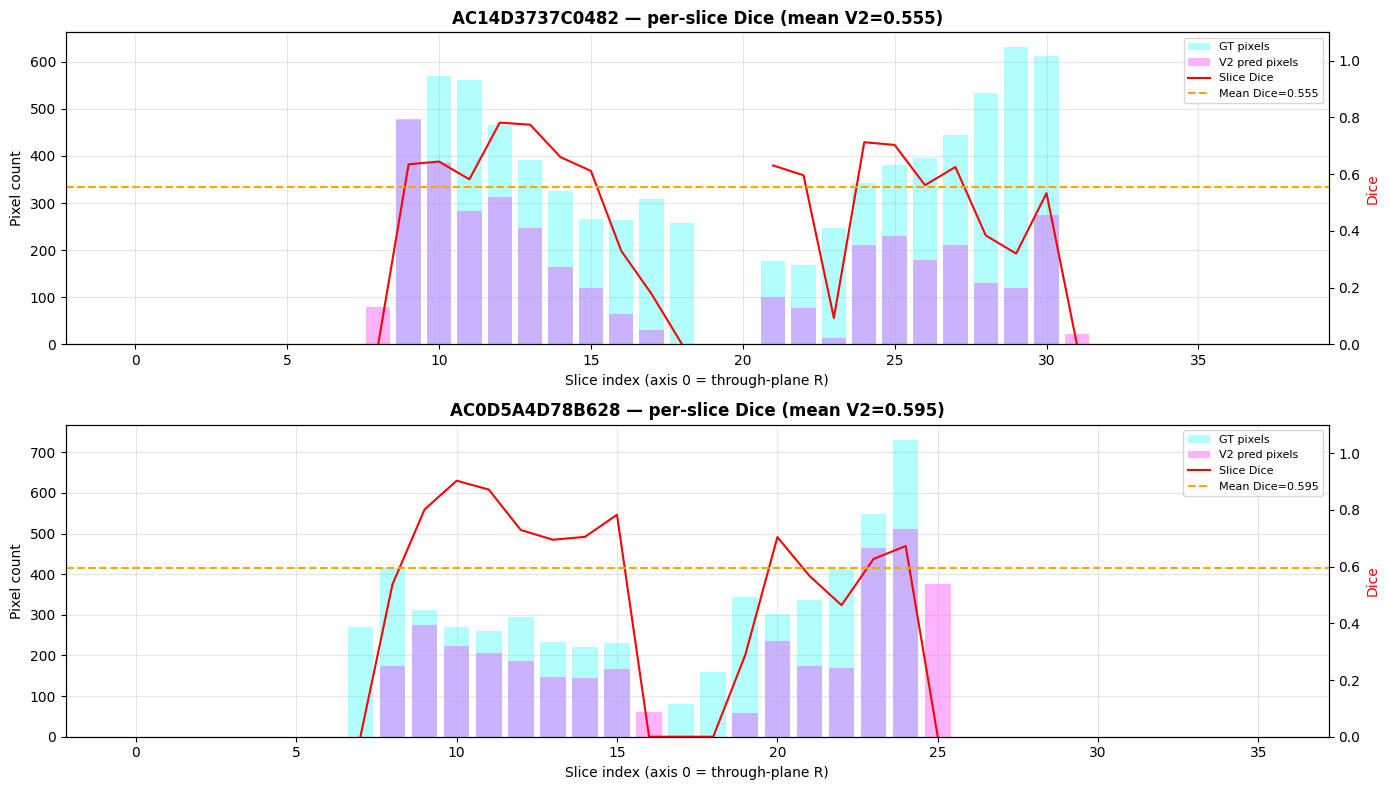

In [67]:
# ── Per-slice Dice for worst 2 patients — see WHERE the model fails ──────────
# Shows slice-by-slice Dice so you can tell if model fails on ALL slices
# or only on specific slices (e.g. edge slices, slices with thin meniscus)

worst2 = sorted(results, key=lambda x: x["dice_v2"])[:2]

fig, axes = plt.subplots(len(worst2), 1, figsize=(14, 4 * len(worst2)), facecolor="white")
if len(worst2) == 1:
    axes = [axes]

for ax, r in zip(axes, worst2):
    gt = (r["_gt"] == 1).astype(bool)   # (D, 384, 384)
    v2 = merge_meniscus_v1v2(r["_v2"])

    slice_dice = []
    for s in range(gt.shape[0]):
        gt_s = gt[s];  v2_s = v2[s]
        tp = (v2_s & gt_s).sum()
        denom = v2_s.sum() + gt_s.sum()
        slice_dice.append(float(2 * tp / denom) if denom > 0 else float("nan"))

    gt_coverage   = gt.sum(axis=(1, 2))   # GT meniscus pixels per slice
    pred_coverage = v2.sum(axis=(1, 2))   # V2 predicted pixels per slice

    slices = range(gt.shape[0])
    ax2 = ax.twinx()

    ax.bar(slices, gt_coverage,   alpha=0.3, color="cyan",    label="GT pixels")
    ax.bar(slices, pred_coverage, alpha=0.3, color="magenta", label="V2 pred pixels")
    ax2.plot(slices, slice_dice, color="red", linewidth=1.5, label="Slice Dice")
    ax2.axhline(r["dice_v2"], color="orange", linestyle="--",
                label=f"Mean Dice={r['dice_v2']:.3f}")
    ax2.set_ylim(0, 1.1)
    ax2.set_ylabel("Dice", color="red")

    ax.set_xlabel("Slice index (axis 0 = through-plane R)")
    ax.set_ylabel("Pixel count")
    ax.set_title(f"{r['patient']} — per-slice Dice (mean V2={r['dice_v2']:.3f})", fontweight="bold")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{BASE}/per_slice_dice_worst.png", dpi=150)
plt.show()

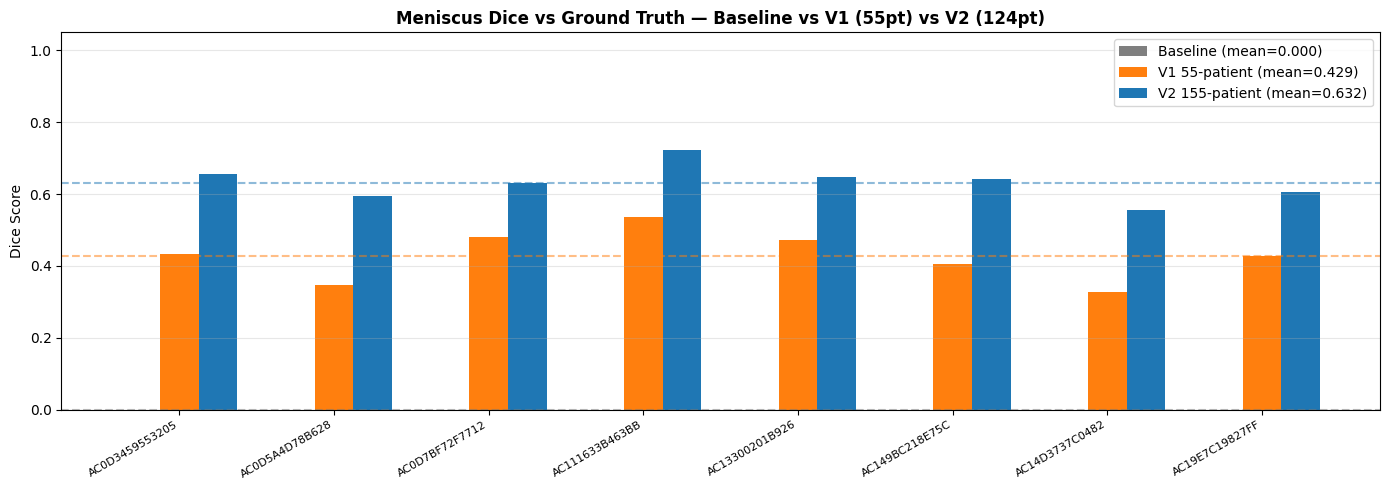

In [68]:
# ── Bar chart: Dice per patient ──────────────────────────────────────────────
patients  = [r["patient"] for r in results]
dice_bl   = [r["dice_bl"] for r in results]
dice_v1   = [r["dice_v1"] for r in results]
dice_v2   = [r["dice_v2"] for r in results]

x   = np.arange(len(patients))
w   = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w, dice_bl, w, label=f"Baseline (mean={mean_bl:.3f})", color="tab:gray")
ax.bar(x,     dice_v1, w, label=f"V1 55-patient (mean={mean_v1:.3f})", color="tab:orange")
ax.bar(x + w, dice_v2, w, label=f"V2 155-patient (mean={mean_v2:.3f})", color="tab:blue")

ax.axhline(mean_bl, color="tab:gray",   linestyle="--", alpha=0.5)
ax.axhline(mean_v1, color="tab:orange", linestyle="--", alpha=0.5)
ax.axhline(mean_v2, color="tab:blue",   linestyle="--", alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(patients, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Dice Score")
ax.set_ylim(0, 1.05)
ax.set_title("Meniscus Dice vs Ground Truth — Baseline vs V1 (55pt) vs V2 (124pt)", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE}/dice_comparison.png", dpi=150)
plt.show()

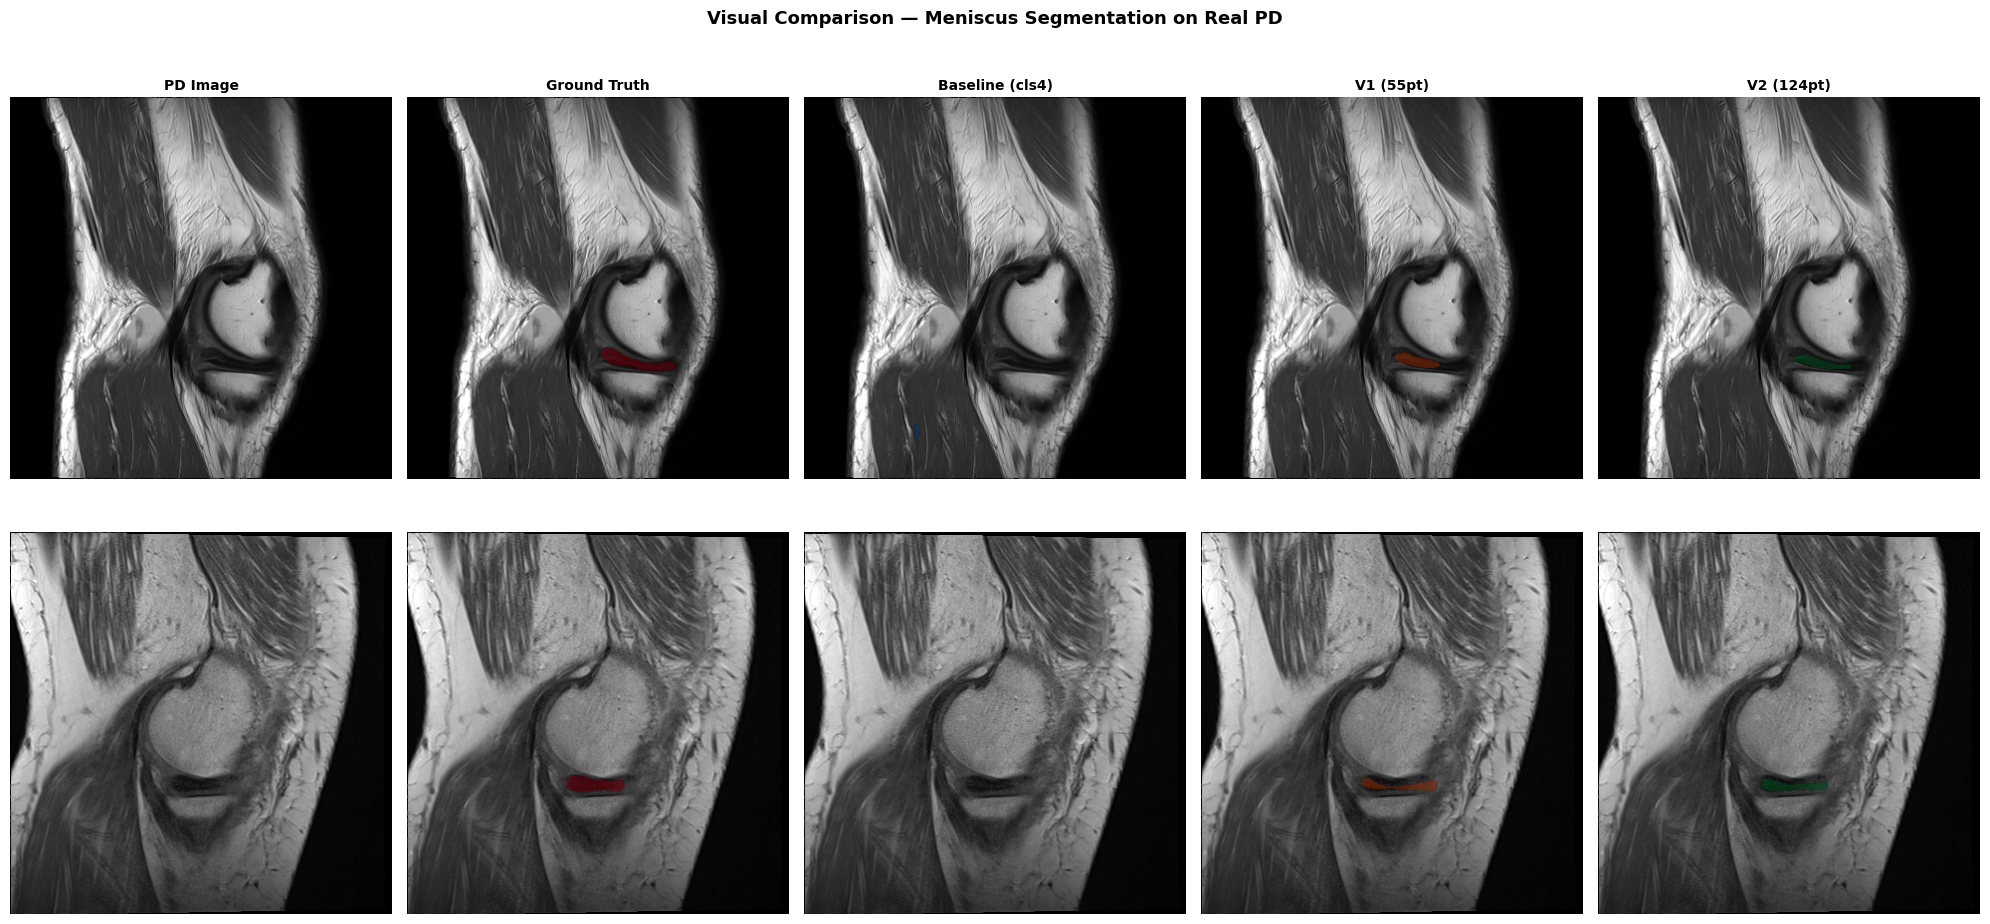

In [69]:
VIZ_PATIENTS = common[:2]

fig, axes = plt.subplots(len(VIZ_PATIENTS), 5, figsize=(20, 5 * len(VIZ_PATIENTS)))
if len(VIZ_PATIENTS) == 1:
    axes = axes.reshape(1, -1)

col_titles = ["PD Image", "Ground Truth", "Baseline (cls4)", "V1 (55pt)", "V2 (124pt)"]
cmaps_mask  = ["Reds", "Blues", "Oranges", "Greens"]

for row, pid in enumerate(VIZ_PATIENTS):
    r = next(x for x in results if x["patient"] == pid)
    gt = r["_gt"];  v1 = r["_v1"];  v2 = r["_v2"];  bl = r["_bl"]

    gt_bin = (gt == 1).astype(bool)
    v1_bin = merge_meniscus_v1v2(v1)
    v2_bin = merge_meniscus_v1v2(v2)
    bl_bin = merge_meniscus_baseline(bl)

    # Best slice = most GT meniscus pixels; all volumes share axis 0 = slices
    best_sl = int(np.argmax(gt_bin.sum(axis=(1, 2))))

    gt_sl = gt_bin[best_sl]
    v1_sl = v1_bin[best_sl]
    v2_sl = v2_bin[best_sl]
    bl_sl = bl_bin[best_sl]

    # PD image: apply same pipeline preprocessing for viz background
    pd_files = glob.glob(os.path.join(PD_DIR, f"{pid}*.nii*"))
    if pd_files:
        pd_vol = preprocess_pd_image(pd_files[0])   # (n_R, 384, 384), [0,1]
        # Match slice count to GT if different (edge case)
        if pd_vol.shape[0] != gt.shape[0]:
            pd_vol = zoom(pd_vol, (gt.shape[0] / pd_vol.shape[0], 1.0, 1.0), order=3)
        pd_sl = pd_vol[best_sl]
    else:
        pd_sl = np.zeros((384, 384), dtype=float)

    masks = [gt_sl, bl_sl, v1_sl, v2_sl]

    for col in range(5):
        ax = axes[row, col]
        ax.imshow(pd_sl.T, cmap="gray", origin="lower", vmin=0, vmax=1)
        if col > 0:
            mask = masks[col - 1]
            ax.imshow(np.ma.masked_equal(mask.T.astype(float), 0),
                      cmap=cmaps_mask[col - 1], origin="lower", alpha=0.6, vmin=0, vmax=1)
        if row == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight="bold")
        ax.set_ylabel(pid, fontsize=7)
        ax.axis("off")

plt.suptitle("Visual Comparison — Meniscus Segmentation on Real PD", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE}/visual_comparison.png", dpi=150)
plt.show()

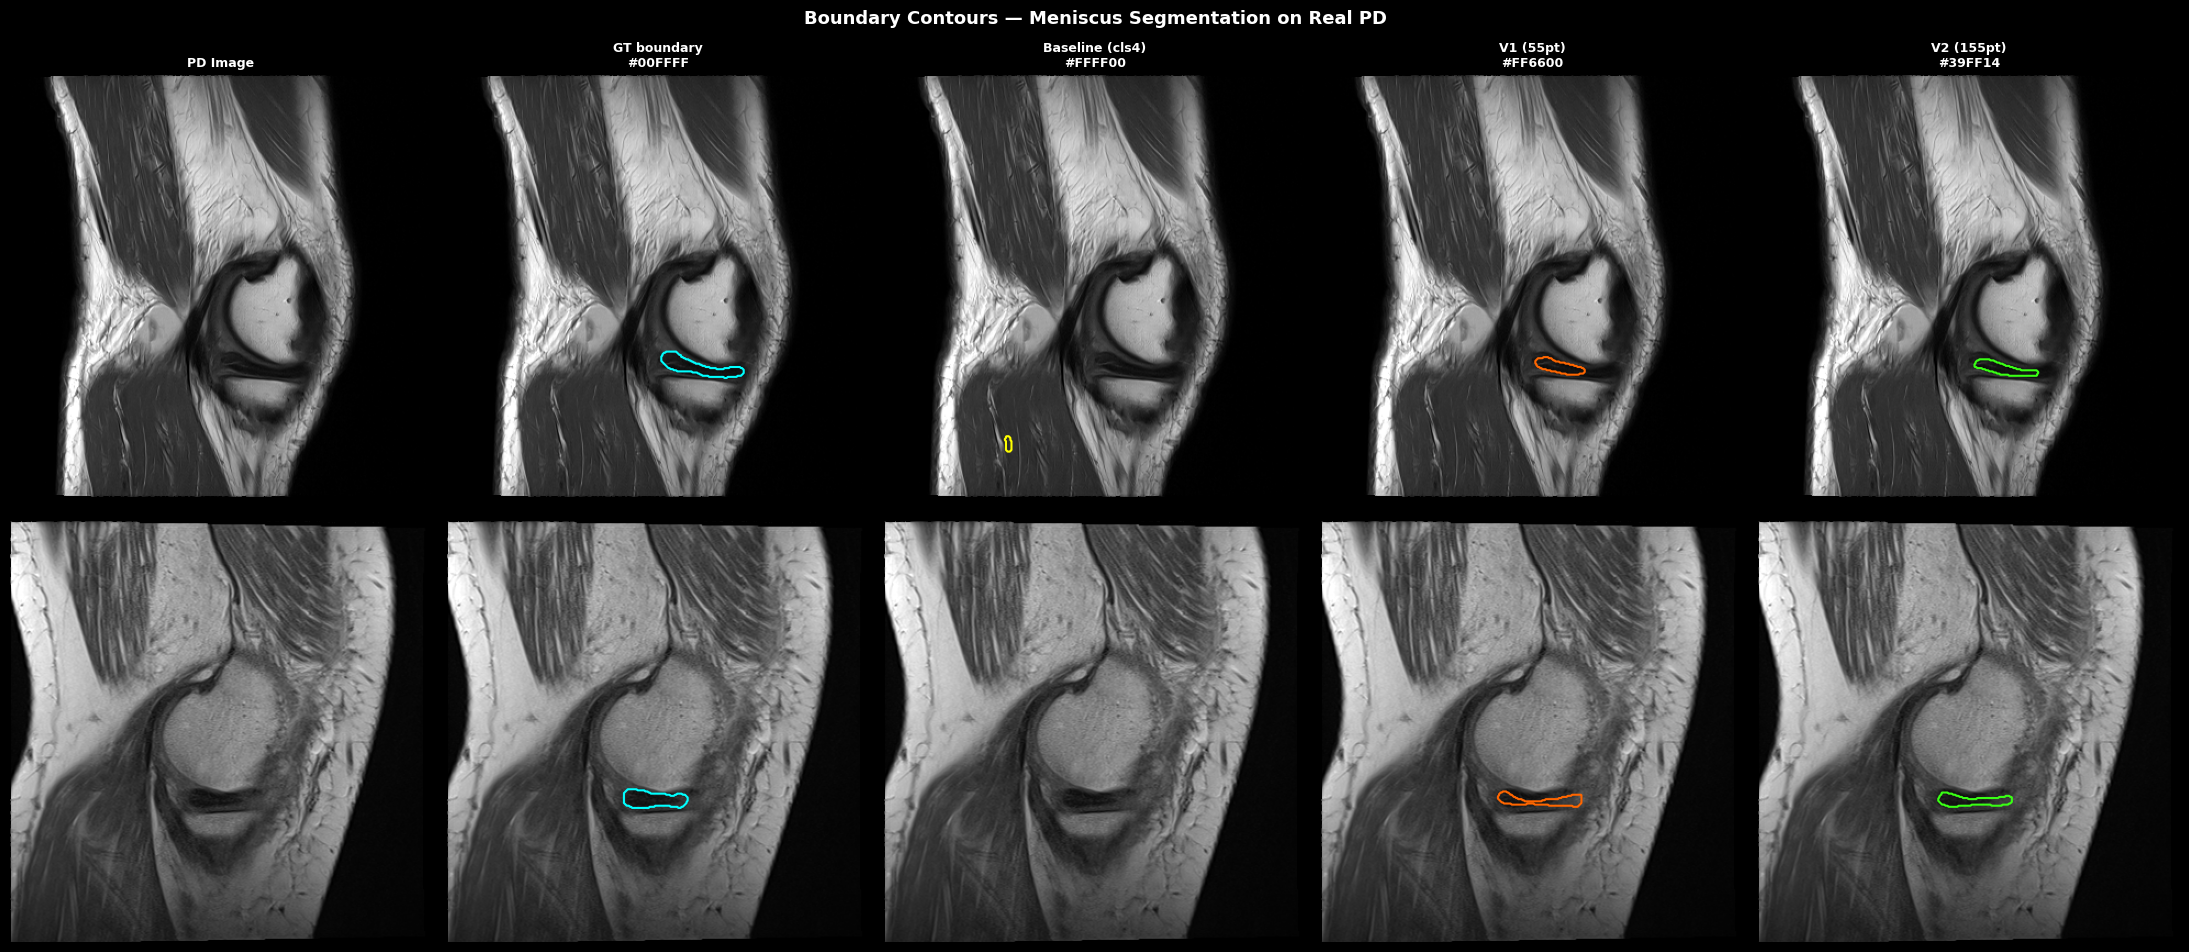

In [70]:
# ── Boundary-only plot (neon contours, no filled overlay) ────────────────────
# ax.contour draws the edge of the binary mask at level 0.5

VIZ_PATIENTS = common[:2]

NEON = {
    "GT":       "#00FFFF",   # neon cyan
    "Baseline": "#FFFF00",   # neon yellow
    "V1":       "#FF6600",   # neon orange
    "V2":       "#39FF14",   # neon green
}

fig, axes = plt.subplots(len(VIZ_PATIENTS), 5, figsize=(22, 5 * len(VIZ_PATIENTS)),
                          facecolor="black")
if len(VIZ_PATIENTS) == 1:
    axes = axes.reshape(1, -1)

col_titles = ["PD Image", f"GT boundary\n{NEON['GT']}",
              f"Baseline (cls4)\n{NEON['Baseline']}",
              f"V1 (55pt)\n{NEON['V1']}",
              f"V2 (155pt)\n{NEON['V2']}"]

for row, pid in enumerate(VIZ_PATIENTS):
    r = next(x for x in results if x["patient"] == pid)
    gt = r["_gt"];  v1 = r["_v1"];  v2 = r["_v2"];  bl = r["_bl"]

    gt_bin = (gt == 1).astype(bool)
    v1_bin = merge_meniscus_v1v2(v1)
    v2_bin = merge_meniscus_v1v2(v2)
    bl_bin = merge_meniscus_baseline(bl)

    best_sl = int(np.argmax(gt_bin.sum(axis=(1, 2))))

    pd_files = glob.glob(os.path.join(PD_DIR, f"{pid}*.nii*"))
    if pd_files:
        pd_vol = preprocess_pd_image(pd_files[0])
        if pd_vol.shape[0] != gt.shape[0]:
            pd_vol = zoom(pd_vol, (gt.shape[0] / pd_vol.shape[0], 1.0, 1.0), order=3)
        pd_sl = pd_vol[best_sl]
    else:
        pd_sl = np.zeros((384, 384), dtype=float)

    masks = [gt_bin[best_sl], bl_bin[best_sl], v1_bin[best_sl], v2_bin[best_sl]]
    colors = [NEON["GT"], NEON["Baseline"], NEON["V1"], NEON["V2"]]

    for col in range(5):
        ax = axes[row, col]
        ax.set_facecolor("black")
        ax.imshow(pd_sl.T, cmap="gray", origin="lower", vmin=0, vmax=1)
        if col > 0:
            mask = masks[col - 1]
            if mask.any():
                ax.contour(mask.T, levels=[0.5], colors=[colors[col - 1]], linewidths=1.5)
        if row == 0:
            ax.set_title(col_titles[col], fontsize=9, fontweight="bold", color="white")
        ax.set_ylabel(pid, fontsize=7, color="white")
        ax.tick_params(colors="white")
        ax.axis("off")

plt.suptitle("Boundary Contours — Meniscus Segmentation on Real PD", fontsize=13,
             fontweight="bold", color="white")
plt.tight_layout()
plt.savefig(f"{BASE}/boundary_comparison.png", dpi=150, facecolor="black")
plt.show()

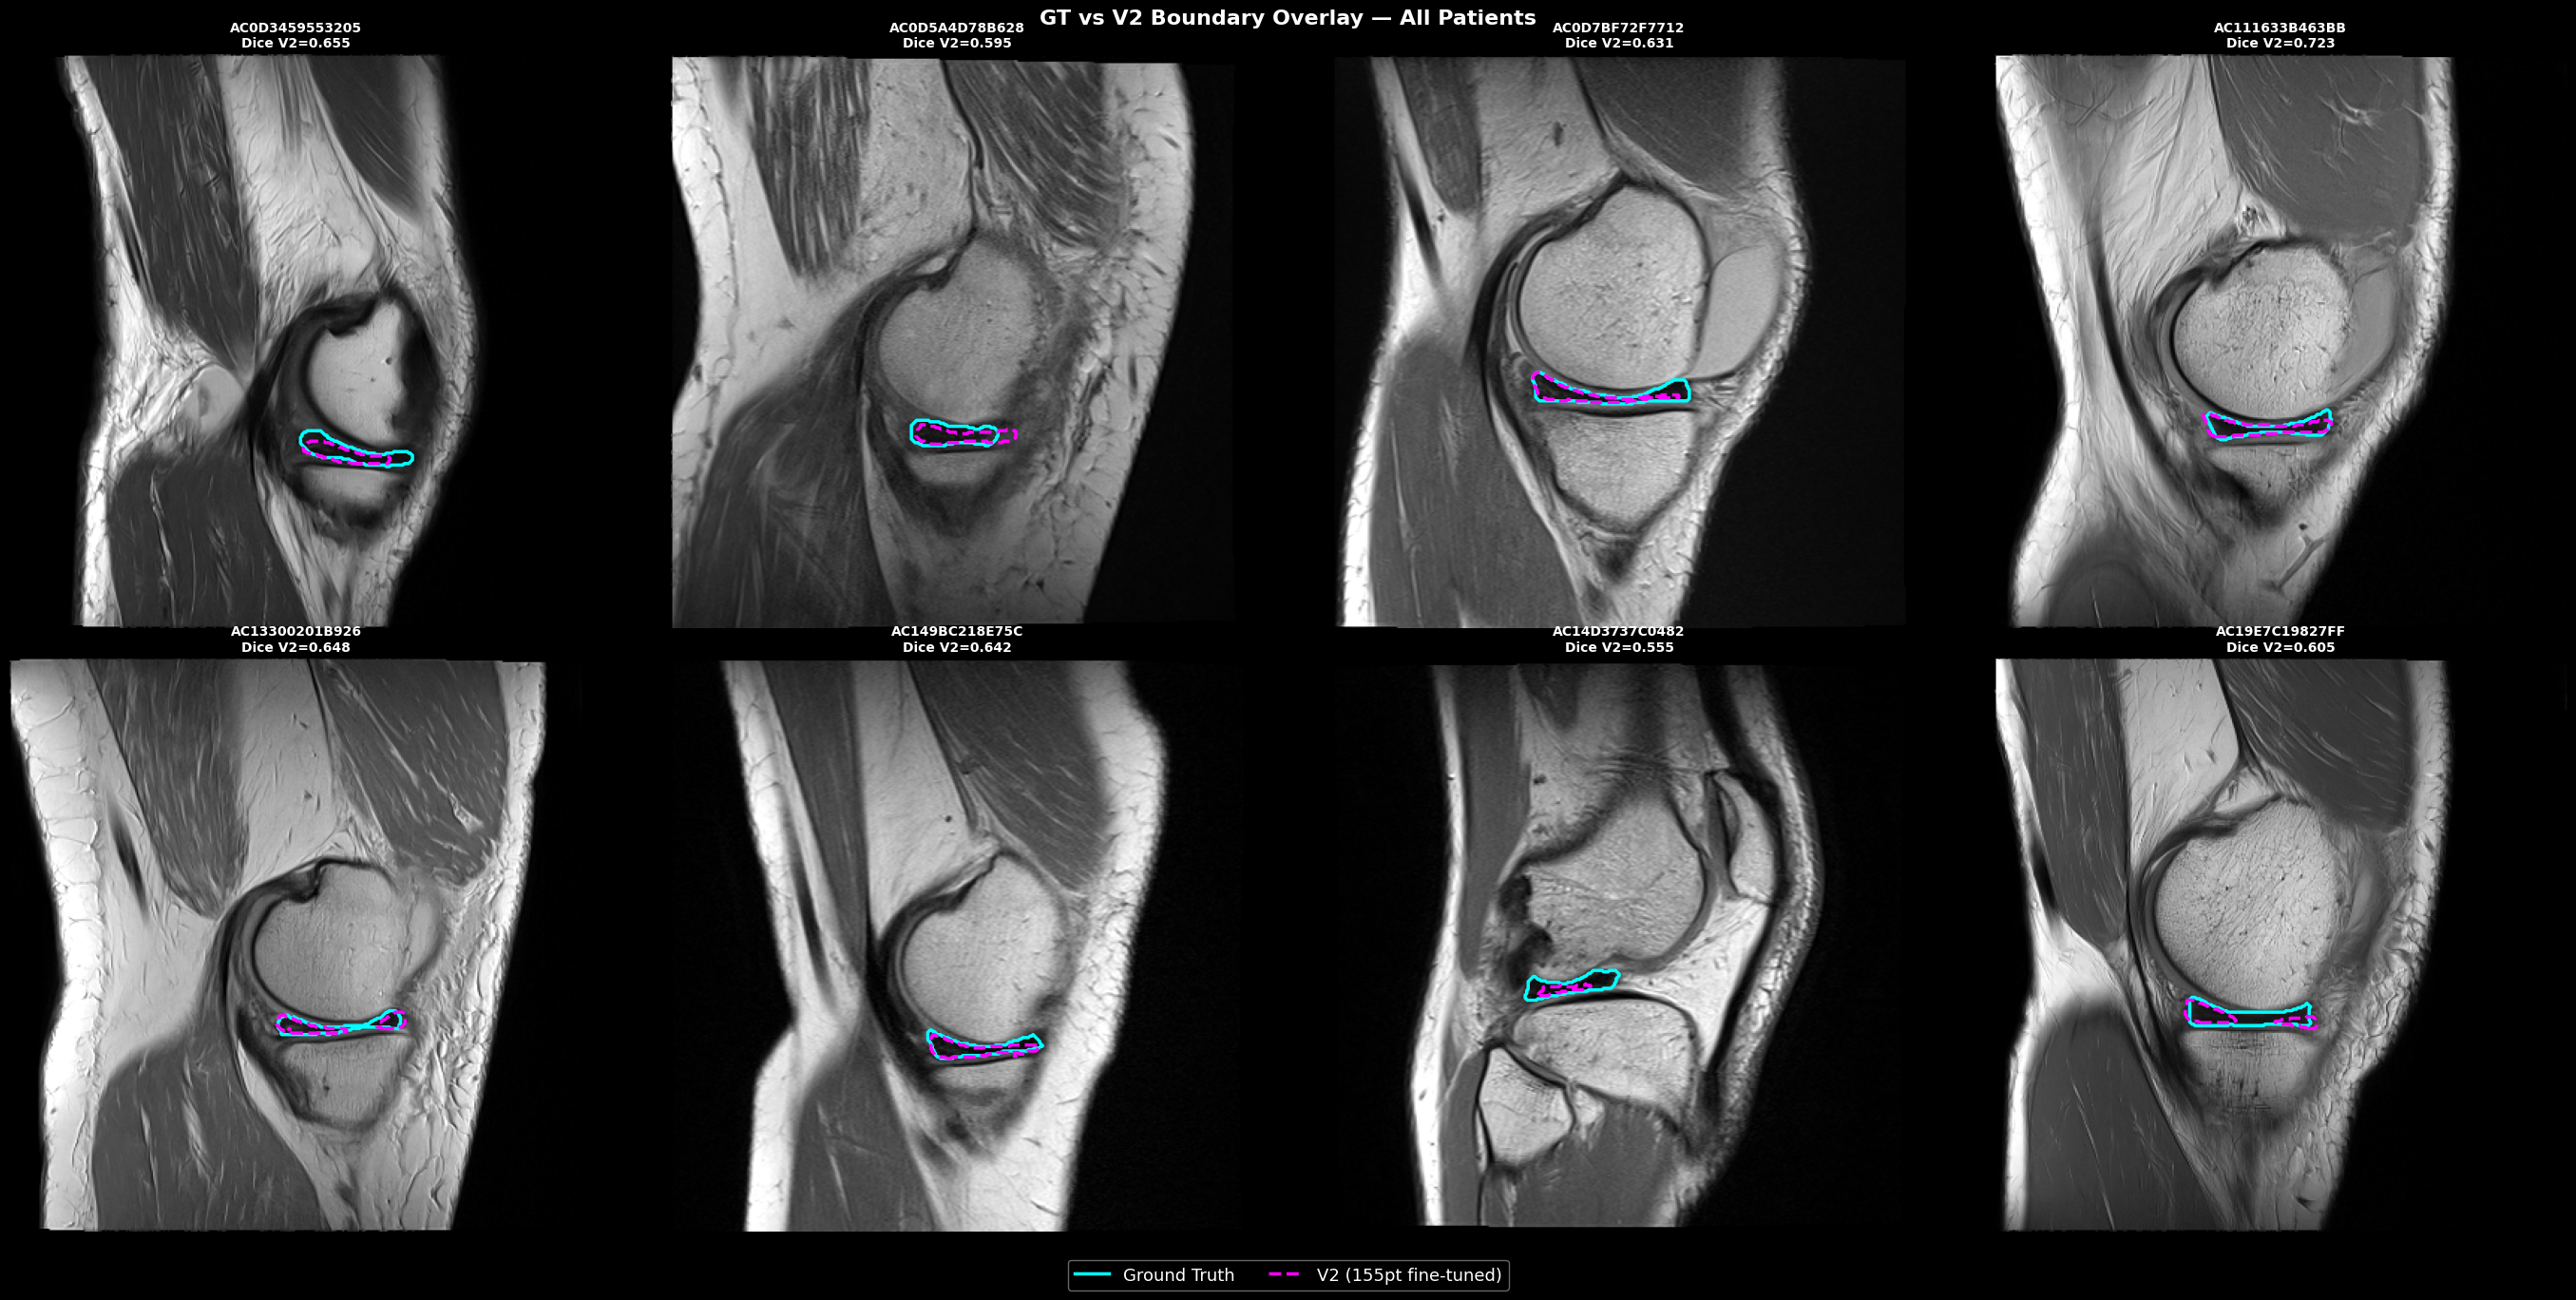

In [71]:
# ── GT + V2 dual-boundary overlay — 2 rows x 4 cols ─────────────────────────
GT_COLOR = "#00FFFF"    # neon cyan  = Ground Truth
V2_COLOR = "#FF00FF"    # neon magenta = V2 fine-tuned

COLS = 4
ROWS = int(np.ceil(len(common) / COLS))

fig, axes = plt.subplots(ROWS, COLS, figsize=(7 * COLS, 7 * ROWS), facecolor="black")
axes = np.array(axes).reshape(ROWS, COLS)

for idx, pid in enumerate(common):
    row, col = divmod(idx, COLS)
    ax = axes[row, col]

    r = next(x for x in results if x["patient"] == pid)
    gt = r["_gt"];  v2 = r["_v2"]

    gt_bin = (gt == 1).astype(bool)
    v2_bin = merge_meniscus_v1v2(v2)

    best_sl = int(np.argmax(gt_bin.sum(axis=(1, 2))))

    pd_files = glob.glob(os.path.join(PD_DIR, f"{pid}*.nii*"))
    if pd_files:
        pd_vol = preprocess_pd_image(pd_files[0])
        if pd_vol.shape[0] != gt.shape[0]:
            pd_vol = zoom(pd_vol, (gt.shape[0] / pd_vol.shape[0], 1.0, 1.0), order=3)
        pd_sl = pd_vol[best_sl]
    else:
        pd_sl = np.zeros((384, 384), dtype=float)

    ax.set_facecolor("black")
    ax.imshow(pd_sl.T, cmap="gray", origin="lower", vmin=0, vmax=1)

    if gt_bin[best_sl].any():
        ax.contour(gt_bin[best_sl].T, levels=[0.5],
                   colors=[GT_COLOR], linewidths=2.5, linestyles="solid")
    if v2_bin[best_sl].any():
        ax.contour(v2_bin[best_sl].T, levels=[0.5],
                   colors=[V2_COLOR], linewidths=2.5, linestyles="dashed")

    ax.set_title(f"{pid}\nDice V2={r['dice_v2']:.3f}", fontsize=10,
                 color="white", fontweight="bold")
    ax.axis("off")

# Hide unused axes
for idx in range(len(common), ROWS * COLS):
    row, col = divmod(idx, COLS)
    axes[row, col].set_visible(False)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=GT_COLOR, linewidth=2.5, linestyle="solid",  label="Ground Truth"),
    Line2D([0], [0], color=V2_COLOR, linewidth=2.5, linestyle="dashed", label="V2 (155pt fine-tuned)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2,
           fontsize=13, facecolor="black", labelcolor="white",
           framealpha=0.5, bbox_to_anchor=(0.5, 0.01))

plt.suptitle("GT vs V2 Boundary Overlay — All Patients", fontsize=16,
             fontweight="bold", color="white")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f"{BASE}/gt_vs_v2_boundaries.png", dpi=150, facecolor="black",
            bbox_inches="tight")
plt.show()

In [72]:
# ── Summary table ────────────────────────────────────────────────────────────
print(f"{'Patient':<30} {'Baseline':>10} {'V1 (55pt)':>10} {'V2 (124pt)':>12}")
print("-" * 65)
for r in results:
    print(f"{r['patient']:<30} {r['dice_bl']:>10.4f} {r['dice_v1']:>10.4f} {r['dice_v2']:>12.4f}")
print("-" * 65)
print(f"{'MEAN':<30} {mean_bl:>10.4f} {mean_v1:>10.4f} {mean_v2:>12.4f}")

Patient                          Baseline  V1 (55pt)   V2 (124pt)
-----------------------------------------------------------------
AC0D3459553205                     0.0000     0.4326       0.6547
AC0D5A4D78B628                     0.0000     0.3469       0.5948
AC0D7BF72F7712                     0.0000     0.4791       0.6313
AC111633B463BB                     0.0000     0.5370       0.7226
AC13300201B926                     0.0000     0.4733       0.6475
AC149BC218E75C                     0.0000     0.4059       0.6417
AC14D3737C0482                     0.0002     0.3276       0.5550
AC19E7C19827FF                     0.0000     0.4280       0.6054
-----------------------------------------------------------------
MEAN                               0.0000     0.4288       0.6316
